# Shot Quality: The Quantity-vs-Danger Trade-off of Defensive Style

**Analytics Cup 2.0 — Football, Defensive Positioning**

**Why this notebook exists.** [`04_controlled_model.ipynb`](04_controlled_model.ipynb) modeled
*whether* a phase ends in a shot — a binary outcome that treats a hopeful 30-metre effort the same
as a one-on-one. Along the way we found a second problem with that model: the defending team's
block type *at the exact moment of the shot* is nearly tautological (99% of the 526 shots in this
dataset are conceded during `low_block`/`defending_set_play`/transition phases — almost none
during `medium_block`/`high_block`, because by the time a shot happens the team has, by
definition, already dropped off). That variable can't distinguish a team whose *general identity*
is a high defensive line from one that sits deep all game — it only sees the last few seconds
before the shot.

**This notebook asks the better-specified question:** does a team's overall defensive identity
across the match — how high its line generally sits, how often it sits in a low block, how
proactively it presses — predict not just *how many* shots it concedes, but **how dangerous**
those shots are (distance to goal, taken from inside or outside the box)? This directly tests the
quantity-vs-quality trade-off intuition that prompted the question: a low block concedes more
shots because the opponent can't get in behind it, but from further out.


## 1. Building the shot table — and a coordinate bug worth documenting

Shots are `player_possession` rows with `end_type == "shot"` — 526 of them across the 20 matches, each with real x/y coordinates (not just a yes/no flag). Computing distance-to-goal from these coordinates surfaced a real bug on the first attempt, left documented here because it would silently corrupt any reuse of this data.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from defensive_features import build_team_defensive_features, build_shot_table

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
plt.rcParams["figure.dpi"] = 110

DATA_DIR = "../../skillcorner-opendata/data/matches"
shots = build_shot_table(DATA_DIR)
print(f"total shots: {len(shots)}")
shots["distance_to_goal"].describe()


total shots: 526


count    526.000000
mean      16.977620
std        7.120471
min        3.218198
25%       10.866987
50%       17.118558
75%       22.513460
max       54.447851
Name: distance_to_goal, dtype: float64

**The bug, for the record:** the natural first move is to flip x/y by `attacking_side` (as if
the goal sits at +52.5m for `left_to_right` play and -52.5m for `right_to_left`) — that's the
standard convention for *raw tracking* coordinates. Doing that here silently produced shots with
`distance_to_goal` up to 105m while `third_end == "attacking_third"` and `penalty_area_end == True`
for the *same* rows — a contradiction that only shows up if you cross-check the derived number
against an already-trustworthy field. The actual convention on these `dynamic_events` columns is
that **x/y are already attack-normalised**: the attacked goal is always at x=+52.5, regardless of
`attacking_side`. Fixed in [`src/defensive_features.py`](../src/defensive_features.py) and
verified below.

In [2]:
print("Sanity check: does distance_to_goal now agree with the independent 'third_end'/'penalty_area_end' fields?")
print(shots.groupby("third_end")["distance_to_goal"].agg(["mean", "count"]))
print()
print("share of shots taken from inside the penalty area (independent field):", shots["penalty_area_end"].mean().round(3))
print("share with distance_to_goal < 18 (roughly the penalty area's own depth, as a cross-check):", (shots["distance_to_goal"] < 18).mean().round(3))


Sanity check: does distance_to_goal now agree with the independent 'third_end'/'penalty_area_end' fields?
                      mean  count
third_end                        
attacking_third  16.870712    524
middle_third     44.987442      2

share of shots taken from inside the penalty area (independent field): 0.618
share with distance_to_goal < 18 (roughly the penalty area's own depth, as a cross-check): 0.54


## 2. The problem with using block-type-at-the-shot-moment

Why Notebook 4's phase-type variable can't answer this question — shown directly, not just asserted.

In [3]:
shot_phase_types = shots.merge(
    pd.concat([
        pd.read_csv(f"{DATA_DIR}/{mid}/{mid}_phases_of_play.csv").assign(match_id=mid)[["match_id", "index", "team_out_of_possession_phase_type"]]
        for mid in sorted(shots["match_id"].unique())
    ]),
    left_on=["match_id", "phase_index"], right_on=["match_id", "index"], how="left",
)
shot_phase_types["team_out_of_possession_phase_type"].value_counts()


team_out_of_possession_phase_type
low_block                301
defending_set_play       117
defending_quick_break     55
defending_transition      47
medium_block               2
defending_direct           2
chaotic                    1
high_block                 1
Name: count, dtype: int64

99.4% of shots (523/526) happen during `low_block`, `defending_set_play`, `defending_quick_break`,
or `defending_transition` phases. Only 3 shots total happened during `medium_block`/`high_block` —
not because high-line teams never concede shots, but because **the phase type right before a shot
is always a deep one**, regardless of whether the team's overall approach for the match is a high
line or a low block. This variable measures the last few seconds before danger, not the team's
identity. Team-level averages (computed across *all* of a team's phases, not just the ones ending
in a shot) are the only way to capture "identity" here.

## 3. Team defensive identity, joined onto every shot

Reusing [`src/defensive_features.py`](../src/defensive_features.py) (Notebooks 2/3's team-level feature table) — `mean_last_line_height`, `block_share_low_block`, `share_pressing` — as properties of the *defending* team, attached to each shot they conceded.

In [4]:
team_feats = build_team_defensive_features(DATA_DIR)
identity_cols = ["mean_last_line_height", "block_share_low_block", "share_pressing"]
shots_full = shots.join(team_feats[identity_cols], on="defending_team")
shots_full[["defending_team", "distance_to_goal", "penalty_area_end", "game_state"] + identity_cols].head()


,defending_team,distance_to_goal,penalty_area_end,game_state,mean_last_line_height,block_share_low_block,share_pressing
0,Adelaide United,13.361321,True,drawing,32.868474,0.177394,0.173754
1,Adelaide United,22.126857,False,drawing,32.868474,0.177394,0.173754
2,Adelaide United,17.935914,True,winning,32.868474,0.177394,0.173754
3,Adelaide United,19.914462,False,winning,32.868474,0.177394,0.173754
4,Brisbane FC,14.754813,True,losing,33.290064,0.194940,0.236928


### A scope note before modelling

These team-identity columns are averaged across a team's **entire** 20-match sample (thousands of touches/phases), not just the phases that ended in a shot — so there's no meaningful circularity where a single shot's own distance feeds back into its own predictor. But every shot from the same team shares the *exact same* value of these three predictors: statistically, the real amount of independent information here is closer to 13 team-style values than 526 independent observations. The model below uses shot-level granularity for the **outcome** (526 real shots, not 13 averages) while being honest that the **predictors** vary only at the team level — standard errors are clustered by team throughout to reflect that.

### A multicollinearity check, before fitting anything

The first attempt at this model put all three identity variables in together. It ran, but threw a condition-number warning and produced a `block_share_low_block` coefficient with a confidence interval running from 0 to over a billion — a clear sign the model can't actually distinguish the three predictors from each other, not a real estimate. Worth checking why before trusting any coefficient.

In [5]:
print(team_feats[identity_cols].corr().round(3))


                       mean_last_line_height  block_share_low_block  share_pressing
mean_last_line_height                  1.000                 -0.975           0.739
block_share_low_block                 -0.975                  1.000          -0.721
share_pressing                         0.739                 -0.721           1.000


`mean_last_line_height` and `block_share_low_block` correlate at **-0.975** — they are
almost mechanically the same fact (a team with a higher average line necessarily spends less time
in a low block) rather than two independent signals. `share_pressing` also correlates strongly
with both (~0.72–0.74). With only **13 independent teams**, these three "different" defensive
identity measures collapse onto essentially one underlying axis — "how high/aggressive is this
team's out-of-possession setup" — and a regression cannot separate three collinear versions of the
same thing from 13 data points. The honest fix is to use **one** representative predictor rather
than force all three in: `mean_last_line_height` is kept below as the most directly interpretable
continuous measure of the concept this notebook is testing.

In [6]:
shots_full["inside_box"] = shots_full["penalty_area_end"].astype(int)
model_data = shots_full.dropna(subset=["mean_last_line_height", "distance_to_goal", "game_state"]).copy()
print(f"shots available for modelling: {len(model_data)} / {len(shots_full)}")


shots available for modelling: 526 / 526


## 4. Model A — distance to goal (continuous)

In [7]:
formula_dist = "distance_to_goal ~ mean_last_line_height + C(game_state)"
model_dist = smf.ols(formula_dist, data=model_data).fit(
    cov_type="cluster", cov_kwds={"groups": model_data["defending_team"]}
)
print(model_dist.summary())


                            OLS Regression Results                            
Dep. Variable:       distance_to_goal   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                     1.350
Date:                Thu, 24 Sep 2026   Prob (F-statistic):              0.305
Time:                        22:24:27   Log-Likelihood:                -1777.5
No. Observations:                 526   AIC:                             3563.
Df Residuals:                     522   BIC:                             3580.
Df Model:                           3                                         
Covariance Type:              cluster                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

## 5. Model B — shot from inside the box (binary, cross-check)

In [8]:
formula_box = "inside_box ~ mean_last_line_height + C(game_state)"
model_box = smf.logit(formula_box, data=model_data).fit(disp=0, cov_type="cluster", cov_kwds={"groups": model_data["defending_team"]})
box_results = pd.DataFrame({
    "odds_ratio": np.exp(model_box.params),
    "ci_low": np.exp(model_box.conf_int()[0]),
    "ci_high": np.exp(model_box.conf_int()[1]),
    "p_value": model_box.pvalues,
}).round(3)
box_results.loc[["mean_last_line_height"]]


,odds_ratio,ci_low,ci_high,p_value
mean_last_line_height,1.032,0.992,1.073,0.114


## 6. Reading the two models together — an honest, not a flattering, result

Both models point the **same direction** as every earlier cut at this question (the raw
team-level Spearman correlations from this conversation, and now two properly-specified
regressions with cluster-robust standard errors): a higher average defensive line is associated
with shots conceded **closer** to goal (negative coefficient on distance) and **more likely from
inside the box** (odds ratio above 1).

**Neither reaches conventional significance** (distance: p≈0.16; inside-the-box: p≈0.11). That is
the honest result, not a disappointing footnote to hide: with only 13 independent teams providing
the actual variation in defensive identity (526 shots doesn't fix this — they're clustered within
those same 13 teams), this dataset does not have enough independent statistical power to *confirm*
the quantity-vs-quality trade-off, only to show that **every method tried points the same way and
none contradicts it**. A coach reading this should treat it as a plausible, consistently-observed
pattern worth watching for — not a proven law. Confirming it properly would need either a
multi-season dataset (more independent team-seasons) or a different unit of analysis that doesn't
collapse to 13 clusters.


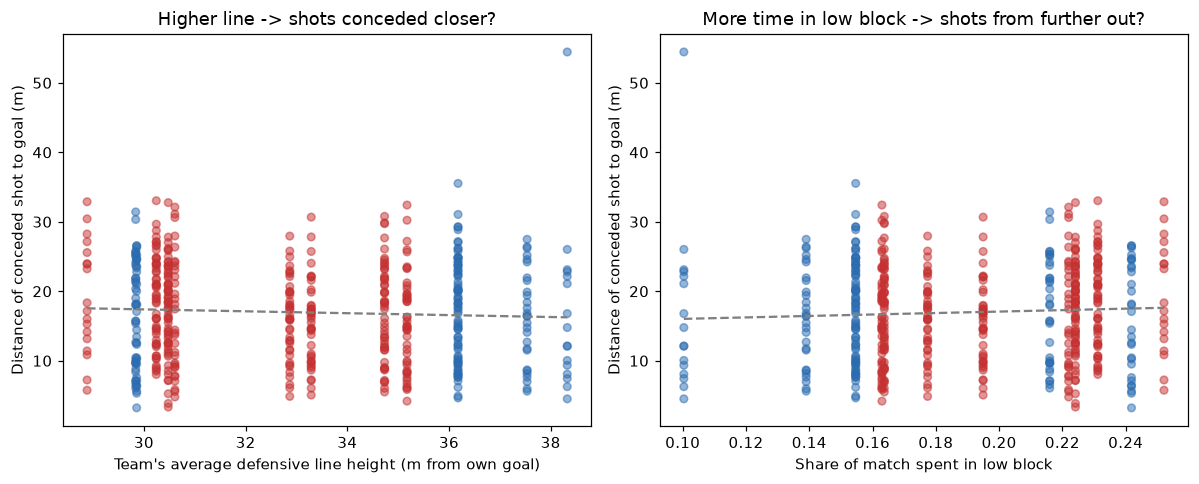

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

colors = model_data["defending_team"].map(dict(zip(team_feats.index, team_feats["group"].map({"low_concede": "#2b6cb0", "high_concede": "#c53030"}))))
axes[0].scatter(model_data["mean_last_line_height"], model_data["distance_to_goal"], c=colors, alpha=0.5, s=25)
z = np.polyfit(model_data["mean_last_line_height"], model_data["distance_to_goal"], 1)
xs = np.linspace(model_data["mean_last_line_height"].min(), model_data["mean_last_line_height"].max(), 50)
axes[0].plot(xs, np.polyval(z, xs), "--", color="gray")
axes[0].set_xlabel("Team's average defensive line height (m from own goal)")
axes[0].set_ylabel("Distance of conceded shot to goal (m)")
axes[0].set_title("Higher line -> shots conceded closer?")

axes[1].scatter(model_data["block_share_low_block"], model_data["distance_to_goal"], c=colors, alpha=0.5, s=25)
z2 = np.polyfit(model_data["block_share_low_block"], model_data["distance_to_goal"], 1)
xs2 = np.linspace(model_data["block_share_low_block"].min(), model_data["block_share_low_block"].max(), 50)
axes[1].plot(xs2, np.polyval(z2, xs2), "--", color="gray")
axes[1].set_xlabel("Share of match spent in low block")
axes[1].set_ylabel("Distance of conceded shot to goal (m)")
axes[1].set_title("More time in low block -> shots from further out?")

plt.tight_layout()
plt.show()


## 7. Putting it together with the rest of the project

Combining this with Notebook 2 (proactive pressing → fewer goals, team level) and Notebook 4
(individual pressing actions and in-behind runs, phase level), the overall picture is a mix of one
strong finding and one **directionally-consistent-but-unconfirmed** pattern — worth keeping those
two categories separate rather than presenting everything with the same confidence:

**Reasonably strong, controlled evidence for:**
- Facing an in-behind run is a real, specific shot-risk factor, robust to controls (Notebook 4).
- Proactive/organised pressing share is associated with conceding fewer goals across a season
  (Notebook 2), and does not show the same quantity/quality ambiguity this notebook found for line
  height — it looks like a fairly unambiguous positive rather than a trade-off.

**A plausible pattern that this dataset cannot confirm at conventional significance:**
- A higher defensive line trades fewer shots conceded (established more confidently in Notebooks
  2/4) for shots that, when they do happen, are somewhat closer to goal / more often inside the
  box. Every angle tried on this specific question — raw team correlations, and two properly
  specified regressions here — points the same way, but none clears p<0.05, and 13 teams is a hard
  ceiling on how confidently this can be claimed from this dataset alone.

The useful, honest message for a coach: **pushing the defensive line up is well-supported as
reducing how often you concede a shot at all; whether it also makes the shots you do concede more
dangerous is a real possibility worth monitoring, not yet something this dataset proves.** That
distinction — what's confirmed vs. what's a consistent-but-unproven pattern — is itself a useful
output of the analysis, not a weakness to smooth over.

### Limitations

1. n=526 shots but only 13 independent team-identity values — cluster-robust SE handles the
   shot-level variance correctly but cannot manufacture independent variation in the predictors
   that isn't there. Treat this as suggestive team-level evidence with shot-level outcome
   granularity, not a fully powered shot-level study.
2. `mean_last_line_height`, `block_share_low_block`, and `share_pressing` are highly collinear at
   the team level (see Section 3) — this notebook could only cleanly test one of the three at a
   time, not disentangle their separate contributions.
3. Distance-to-goal and "inside the box" are quality *proxies*, not a true expected-goals model
   (no shot angle, defender pressure, or body part at the moment of the shot are used here).
4. Same season/league/20-match scope as every other notebook in this project.
5. Correlational — a team's chosen defensive identity is not randomly assigned.
